### 1. Imports & Setup

Import the libraries used throughout the notebook and load the raw dataset.
We also create a working copy of the DataFrame so the original data stays unchanged.

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer

# Configure visualization style
sns.set_style("whitegrid")
%matplotlib inline

print("Libraries imported successfully.")

# Load the dataset
df = pd.read_csv('data/customer_info.csv')

# Create a working copy to preserve original data
data = df.copy()

Libraries imported successfully.


### 2. Data Preparation

Prepare the dataset for consistent processing.
This includes setting a reliable index (customer ID when available), removing duplicates, and quickly validating the result.

In [121]:
# Set customer_id as the index
if 'customer_id' in data.columns:
    data.set_index('customer_id', inplace=True)

# Check and remove duplicate rows
initial_count = len(data)
data.drop_duplicates(inplace=True)
dropped_count = initial_count - len(data)

print(f"Original rows: {initial_count}")
print(f"Duplicates dropped: {dropped_count}")
print(f"Current rows: {len(data)}")

# Display the first few rows to verify
display(data.head())

Original rows: 16978
Duplicates dropped: 0
Current rows: 16978


,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,
11259,Louis Huffman,male,08/22/1948 05:06 AM,0.0,2.0,2.0,3.0,6238.0,818.0,18.0,...,1039.0,361.0,457.0,1520.0,210.0,0.623414,2000.0,917650.0,38.683897,-9.172942
6538,Msc. Noel Ward,male,02/12/1967 07:51 PM,2.0,1.0,3.0,3.0,4188.0,1048.0,14.0,...,1913.0,562.0,67.0,957.0,92.0,0.555637,2017.0,906928.0,38.790490,-9.115064
14274,Bsc. Scott Giordano,male,04/10/1986 05:10 PM,0.0,0.0,1.0,1.0,25269.0,4047.0,12.0,...,303.0,724.0,442.0,1213.0,85.0,0.259248,2014.0,958107.0,38.775609,-9.112610
7796,William Lacy,male,01/03/1999 01:47 AM,0.0,1.0,1.0,3.0,8292.0,1524.0,15.0,...,1877.0,560.0,1028.0,1005.0,169.0,0.419730,2024.0,967864.0,38.736641,-9.158548
4521,Bsc. Nathan Minor,male,10/21/1957 07:34 AM,3.0,1.0,2.0,3.0,43692.0,3718.0,10.0,...,3093.0,1635.0,868.0,745.0,345.0,0.428821,2004.0,971603.0,38.726597,-9.109803


### 3. Data Cleaning

Handle missing values so later steps (feature engineering and scaling) can run without errors.
Metric (numeric) features are imputed using KNN; non-metric/categorical features are imputed using the most frequent value (mode).

In [122]:
# Check for missing values
missing_values = data.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

# ---------------------------------------------------------
# SETUP: Feature Classification
# ---------------------------------------------------------
# Identifiers / Descriptors / Categories
non_metric_features = [
    'customer_name',
    'customer_gender',
    'customer_birthdate',
    'loyalty_card_number',
    'latitude',
    'longitude',
    'year_first_transaction',
    'typical_hour', 
]

# 1. Count Metrics (Integers like 0, 1, 2) -> Use MANUAL LIMITS
count_features = [
    'kids_home', 
    'teens_home', 
    'number_complaints', 
    'distinct_stores_visited',
]

# 2. Continuous Metrics (Money, Time) -> Use CUSTOM IQR
spending_features = [
    'lifetime_spend_groceries', 
    'lifetime_spend_electronics', 
    'lifetime_spend_vegetables', 
    'lifetime_spend_nonalcohol_drinks', 
    'lifetime_spend_alcohol_drinks', 
    'lifetime_spend_meat', 
    'lifetime_spend_fish', 
    'lifetime_spend_hygiene', 
    'lifetime_spend_videogames', 
    'lifetime_spend_petfood', 
    'lifetime_total_distinct_products', 
    'percentage_of_products_bought_promotion'
]

# Combined list for Imputation
metric_features = count_features + spending_features

# Keep only columns that actually exist
non_metric_features = [c for c in non_metric_features if c in data.columns]
metric_features = [c for c in metric_features if c in data.columns]

# Warning for unclassified columns
unclassified_cols = [c for c in data.columns if c not in set(metric_features + non_metric_features)]
if unclassified_cols:
    print('Warning: Unclassified columns:', unclassified_cols)

# ---------------------------------------------------------
# STEP 1: Metric Imputation (Common to both approaches)
# ---------------------------------------------------------
data[metric_features] = data[metric_features].apply(pd.to_numeric, errors='coerce')

print("Applying KNN Imputation...")
imputer = KNNImputer(n_neighbors=5)
data[metric_features] = imputer.fit_transform(data[metric_features])

# ---------------------------------------------------------
# STEP 2 & 3: Branching Approaches for Non-Metric Data
# ---------------------------------------------------------

# === Approach A: Fill with Mode ===
data_mode = data.copy()
for col in non_metric_features:
    mode_values = data_mode[col].mode(dropna=True)
    if not mode_values.empty:
        data_mode[col] = data_mode[col].fillna(mode_values.iloc[0])

print(f"Approach A (Mode) Missing Values: {data_mode.isnull().sum().sum()}")

# === Approach B: Fill with 'Unknown' ===
# (But should not be used due to NaN proliferation)
data_unknown = data.copy()
for col in non_metric_features:
    data_unknown[col] = data_unknown[col].fillna("Unknown")

print(f"Approach B (Unknown) Missing Values: {data_unknown.isnull().sum().sum()}")

Missing values per column:
 customer_birthdate                 68
kids_home                          85
teens_home                         68
number_complaints                  51
distinct_stores_visited           170
typical_hour                       68
lifetime_spend_vegetables          85
lifetime_spend_alcohol_drinks     170
lifetime_spend_fish               170
loyalty_card_number              3143
dtype: int64
Applying KNN Imputation...
Approach A (Mode) Missing Values: 0
Approach B (Unknown) Missing Values: 0


### 4. Detect and Remove Outliers

Inspect and mitigate extreme values that could distort scaling and clustering.
We use visual diagnostics (e.g., boxplots) and apply an outlier treatment strategy before proceeding.

#### 4.1 Indetifying skewed features

Without identifying first the skewed features the outliers removal was greater than 26%.

Skewness Scores:
lifetime_spend_videogames                  2.985067
lifetime_spend_electronics                 2.015034
distinct_stores_visited                    1.679959
kids_home                                  1.059717
number_complaints                          0.949913
lifetime_spend_groceries                   0.940907
lifetime_spend_hygiene                     0.918478
lifetime_spend_meat                        0.826716
teens_home                                 0.727090
lifetime_total_distinct_products           0.724273
lifetime_spend_alcohol_drinks              0.699657
lifetime_spend_fish                        0.671377
lifetime_spend_vegetables                  0.649625
lifetime_spend_nonalcohol_drinks           0.585014
percentage_of_products_bought_promotion    0.423490
lifetime_spend_petfood                     0.057373
dtype: float64


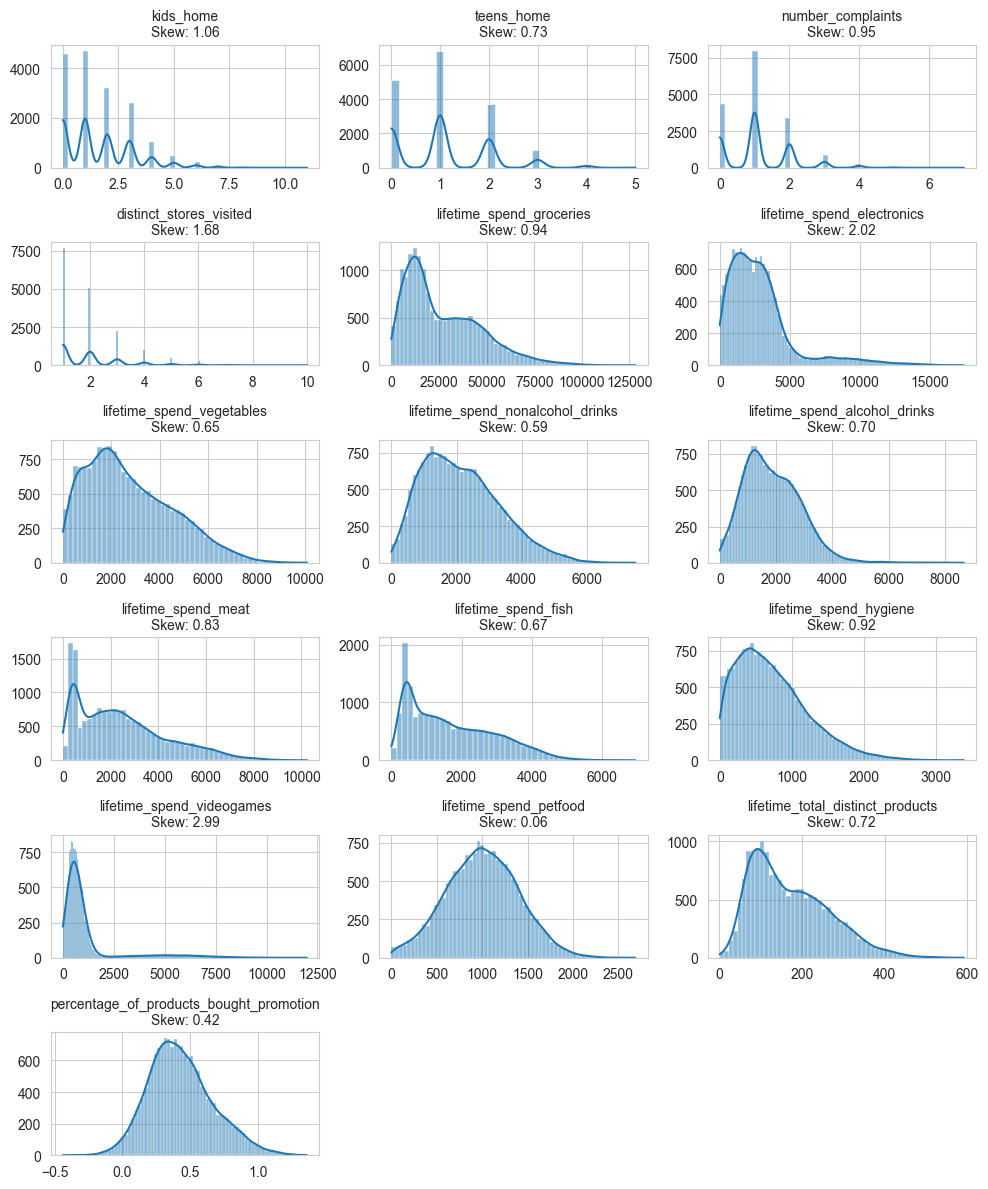

In [123]:
# Ensure numeric types
data[metric_features] = data[metric_features].apply(pd.to_numeric, errors='coerce')

# Calculate Skewness
skewness = data[metric_features].skew().sort_values(ascending=False)
print("Skewness Scores:")
print(skewness)

# Plot Distributions
n_cols = 3
n_rows = (len(metric_features) + n_cols - 1) // n_cols

plt.figure(figsize=(10, 2 * n_rows))

for i, col in enumerate(metric_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data[col].dropna(), kde=True)
    plt.title(f"{col}\nSkew: {skewness[col]:.2f}", fontsize=10)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

#### 4.2. Outliers removal

For highly skewed spending variables, we chose Winsorization (Capping) over removal to preserve high-value customer segments, which are critical for business analysis.

Capping creates a "Ceiling." Everyone above the ceiling is treated as "Maximum Value."
Does it move them? Yes, it pulls them closer to the center.
Do they belong in a different cluster? Usually no. They belong in the "Highest Value Cluster," and capping ensures they stay there without breaking the math for everyone else.

In [124]:
# ---------------------------------------------------------
# REPLACEMENT: Capping Outliers (Winsorization)
# ---------------------------------------------------------
def cap_outliers(df, threshold_dict):
    """
    Instead of removing rows, we cap values at the upper limit.
    This preserves data (0% loss) while fixing outliers.
    """
    df_clean = df.copy()
    
    # Apply capping logic
    for col, thresh in threshold_dict.items():
        # Calculate the Upper Limit only
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        upper_limit = Q3 + thresh * IQR
        
        # Check how many would be capped (just for info)
        outliers = df_clean[col] > upper_limit
        if outliers.sum() > 0:
            print(f"Capping {outliers.sum()} values in {col} at {upper_limit:.2f}")
            
            # The Magic Line: Cap values > limit to the limit
            df_clean.loc[df_clean[col] > upper_limit, col] = upper_limit
            
    return df_clean

# ---------------------------------------------------------
# DEFINE LIMITS (Only for skewed spending columns)
# ---------------------------------------------------------
capping_rules = {
    # High Skew -> Cap at 3.0 or 4.5 IQR (Keep the "Whale" status but remove extreme excess)
    'lifetime_spend_videogames': 3.0,   
    'lifetime_spend_electronics': 3.0,  
    'distinct_stores_visited': 3.0, 
    
    # Moderate Skew -> Cap at 1.5 IQR
    'lifetime_spend_groceries': 1.5,
    'lifetime_spend_meat': 1.5,
    # Add others if you want to cap them too
}

# ---------------------------------------------------------
# EXECUTE
# ---------------------------------------------------------
print("--- Approach A (Capping) ---")
# First, apply the Business Logic (Kids/Complaints) using Filter
# (We still drop these because >5 kids is likely an error, not a 'cap')
data_mode_clean = data_mode[
    (data_mode['kids_home'] <= 5) & 
    (data_mode['number_complaints'] <= 20)
].copy()

# Now apply Capping to spending
data_mode_clean = cap_outliers(data_mode_clean, capping_rules)
print(f"Final shape: {data_mode_clean.shape}")
print(f"Data Loss: {100 - (len(data_mode_clean)/len(data_mode)*100):.2f}% (Should be minimal)")

print("\n--- Approach B (Capping) ---")
# Apply Business Logic first
data_unknown_clean = data_unknown[
    (data_unknown['kids_home'] <= 5) & 
    (data_unknown['number_complaints'] <= 20)
].copy()

# Apply Capping
data_unknown_clean = cap_outliers(data_unknown_clean, capping_rules)

--- Approach A (Capping) ---
Capping 1646 values in lifetime_spend_videogames at 2727.00
Capping 374 values in lifetime_spend_electronics at 10521.00
Capping 386 values in distinct_stores_visited at 5.00
Capping 195 values in lifetime_spend_groceries at 82518.00
Capping 185 values in lifetime_spend_meat at 7372.00
Final shape: (16605, 24)
Data Loss: 2.20% (Should be minimal)

--- Approach B (Capping) ---
Capping 1646 values in lifetime_spend_videogames at 2727.00
Capping 374 values in lifetime_spend_electronics at 10521.00
Capping 386 values in distinct_stores_visited at 5.00
Capping 195 values in lifetime_spend_groceries at 82518.00
Capping 185 values in lifetime_spend_meat at 7372.00


### 5. Featura Engineering

Create more informative variables from the raw columns to better represent customer behavior.
This can include derived fields (totals, tenure, age-like features) and dropping identifiers or non-modeling fields.

In [125]:
# ---------------------------------------------------------
# FUNCTION: Feature Engineering Pipeline (FIXED)
# ---------------------------------------------------------
def engineer_features(df):
    """
    Applies feature engineering (Age, Tenure, Ratios) to a cleaned dataframe.
    """
    data = df.copy()
    
    # 1. Date Conversions (Age & Tenure)
    if 'customer_birthdate' in data.columns:
        # FIX: errors='coerce' turns "Unknown" into NaT (Not a Time)
        data['customer_birthdate'] = pd.to_datetime(data['customer_birthdate'], errors='coerce')
        
        # Calculate Age (NaT will result in NaN age, which is correct for "Unknown")
        data['Age'] = 2025 - data['customer_birthdate'].dt.year

    if 'year_first_transaction' in data.columns:
        # Convert to numeric just in case "Unknown" string is present here too
        data['year_first_transaction'] = pd.to_numeric(data['year_first_transaction'], errors='coerce')
        data['Tenure'] = 2025 - data['year_first_transaction']

    # 2. Total Spend (Recalculate after Capping)
    spend_cols = [col for col in data.columns if 'lifetime_spend_' in col]
    data['Total_Spend'] = data[spend_cols].sum(axis=1)
    
    # 3. Total Minors
    if 'kids_home' in data.columns and 'teens_home' in data.columns:
        # Ensure numeric (coerce "Unknown" to NaN)
        data['kids_home'] = pd.to_numeric(data['kids_home'], errors='coerce')
        data['teens_home'] = pd.to_numeric(data['teens_home'], errors='coerce')
        data['Total_Minors'] = data['kids_home'] + data['teens_home']

    # 4. Wallet Share Ratios
    total_safe = data['Total_Spend'] + 1e-6
    
    data['Share_Fresh_Food'] = (
        data['lifetime_spend_vegetables'] + 
        data['lifetime_spend_meat'] + 
        data['lifetime_spend_fish']
    ) / total_safe

    data['Share_Groceries'] = data['lifetime_spend_groceries'] / total_safe

    data['Share_Tech_Gaming'] = (
        data['lifetime_spend_electronics'] + 
        data['lifetime_spend_videogames']
    ) / total_safe

    data['Share_Drinks'] = (
        data['lifetime_spend_alcohol_drinks'] + 
        data['lifetime_spend_nonalcohol_drinks']
    ) / total_safe
    
    # 5. Behavioral Features
    if 'distinct_stores_visited' in data.columns:
        data['distinct_stores_visited'] = pd.to_numeric(data['distinct_stores_visited'], errors='coerce')
        data['Avg_Spend_Per_Visit'] = data['Total_Spend'] / (data['distinct_stores_visited'] + 1)
        
    # 6. Cleanup
    cols_to_drop = [
        'customer_name', 'customer_birthdate', 'year_first_transaction', 
        'loyalty_card_number', 'latitude', 'longitude', 'customer_gender'
    ]
    data.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    
    data.replace([np.inf, -np.inf], 0, inplace=True)
    
    return data

# ---------------------------------------------------------
# EXECUTE ON BOTH BRANCHES
# ---------------------------------------------------------

# Apply to Branch A
print("--- Engineering Features for Approach A (Mode) ---")
data_mode_final = engineer_features(data_mode_clean)
# Mode approach shouldn't have NaNs, but good to check
print(f"Missing Values in Age: {data_mode_final['Age'].isnull().sum()}")
display(data_mode_final[['Total_Spend', 'Share_Tech_Gaming', 'Age']].head())

--- Engineering Features for Approach A (Mode) ---
Missing Values in Age: 0


,Total_Spend,Share_Tech_Gaming,Age
customer_id,,,
11259,17056.0,0.074754,77
6538,18675.0,0.059705,58
14274,40362.0,0.111218,39
7796,21337.0,0.119604,26
4521,71789.0,0.063882,68


### 6. Correlations

Analyze relationships between numerical variables.
A correlation heatmap helps identify redundant features and understand which variables move together.

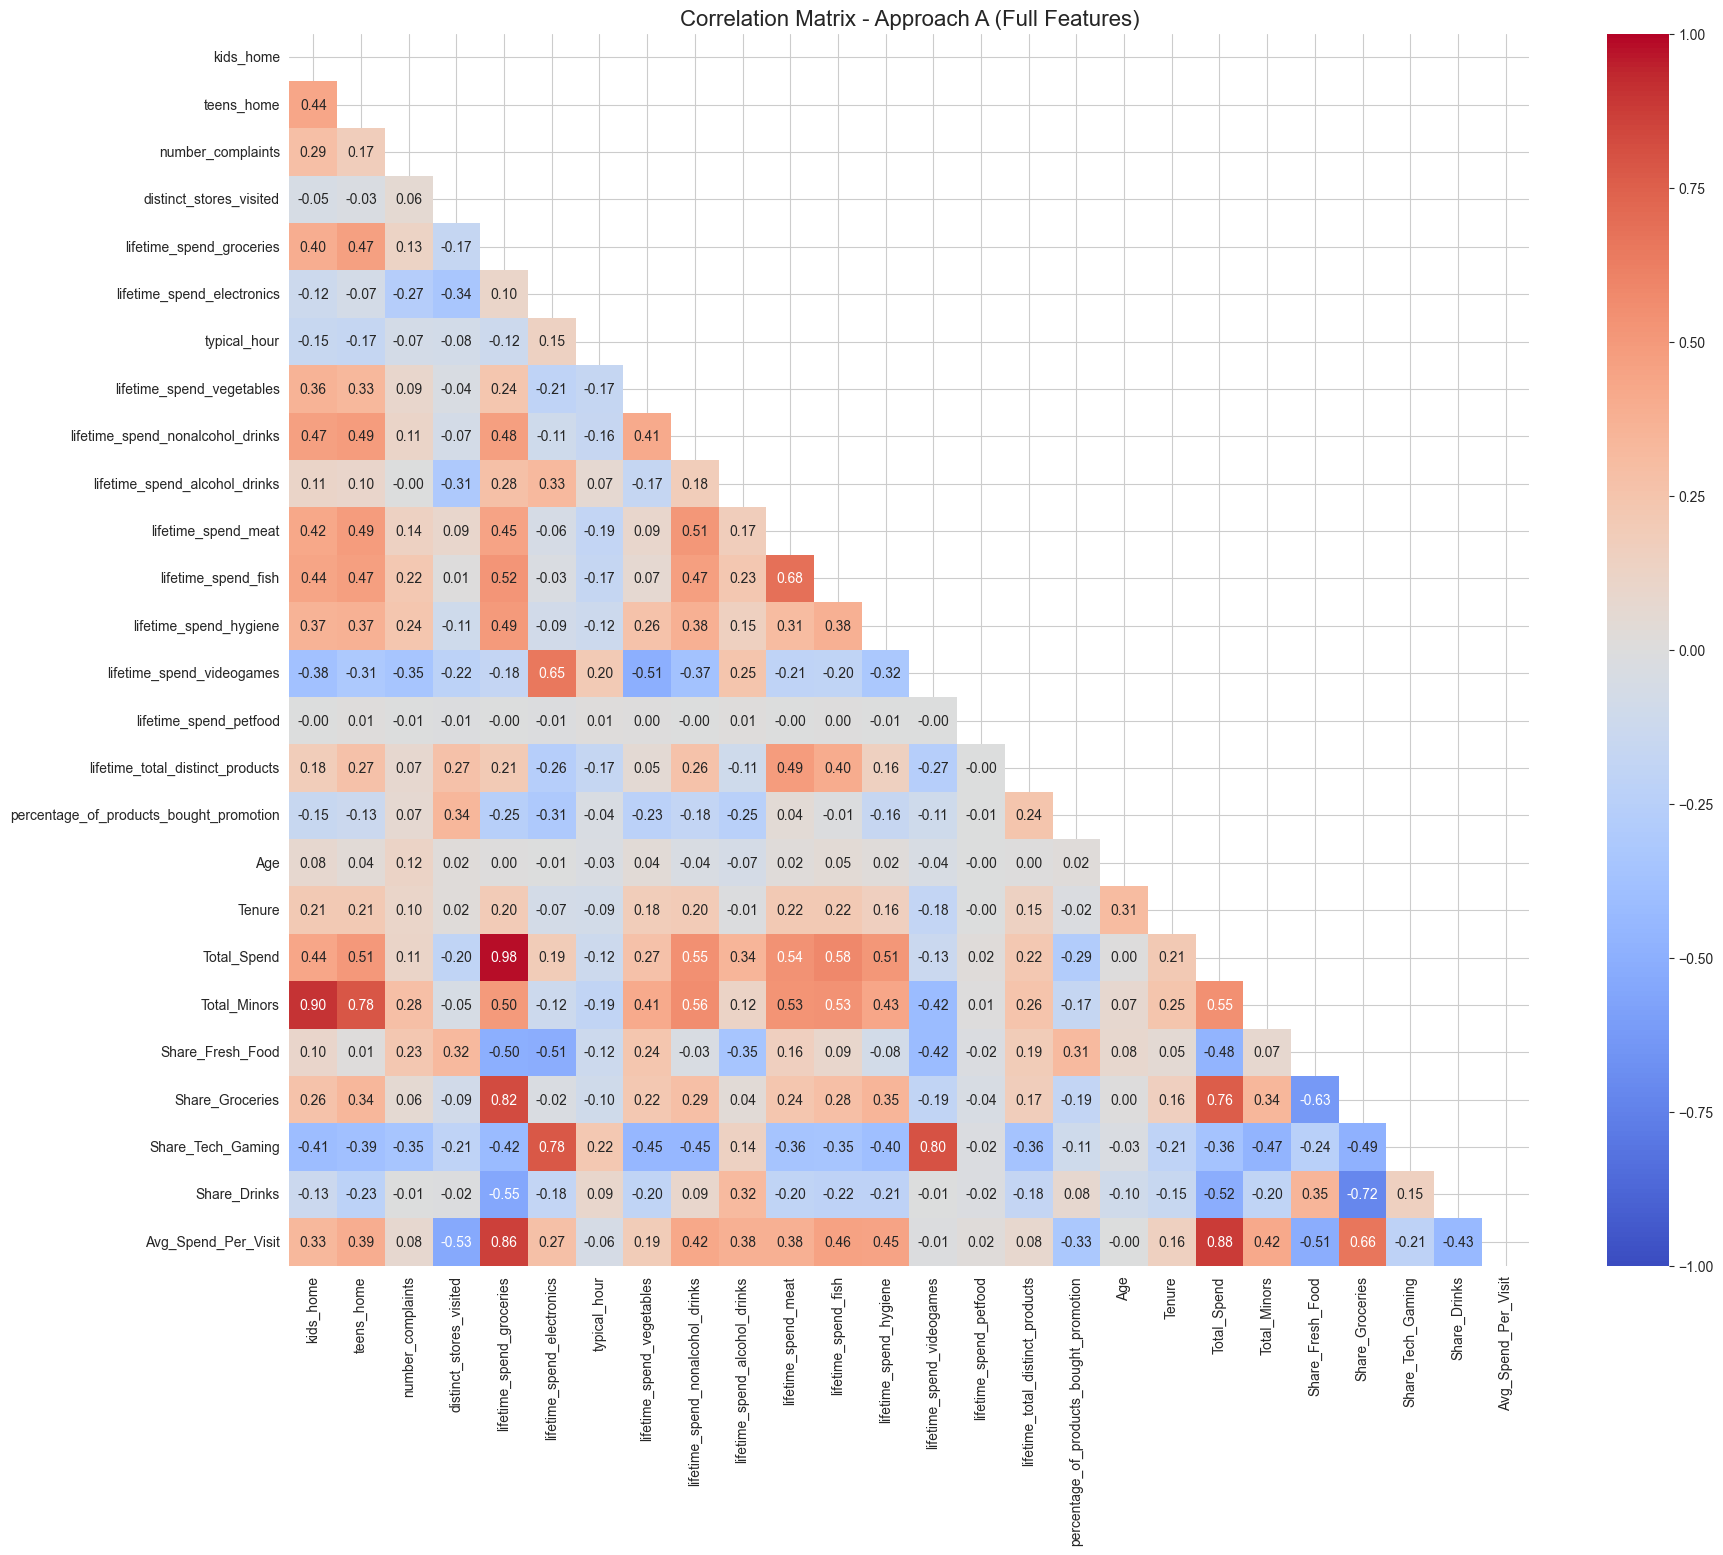

Highly Correlated Pairs (> 0.8):
Total_Spend <--> lifetime_spend_groceries: 0.98
Total_Minors <--> kids_home: 0.90
Share_Groceries <--> lifetime_spend_groceries: 0.82
Share_Tech_Gaming <--> lifetime_spend_videogames: 0.80
Avg_Spend_Per_Visit <--> lifetime_spend_groceries: 0.86
Avg_Spend_Per_Visit <--> Total_Spend: 0.88


In [126]:
# ---------------------------------------------------------
# 6.1 VISUALIZE CORRELATIONS
# ---------------------------------------------------------
def plot_correlation_heatmap(df, title):
    # Select only numeric columns for correlation
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Calculate correlation matrix
    corr_matrix = numeric_df.corr()
    
    # Plot
    plt.figure(figsize=(20, 16))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Hide upper triangle
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0)
    plt.title(title, fontsize=16)
    plt.show()
    
    return corr_matrix

# We check 'data_mode_final' (Approach A) as our representative sample
corr_matrix_A = plot_correlation_heatmap(data_mode_final, "Correlation Matrix - Approach A (Full Features)")

# ---------------------------------------------------------
# 6.2 IDENTIFY HIGH CORRELATIONS (> 0.8)
# ---------------------------------------------------------
# This helps us spot which variables are effectively duplicates
high_corr_pairs = []
for i in range(len(corr_matrix_A.columns)):
    for j in range(i):
        if abs(corr_matrix_A.iloc[i, j]) > 0.8:
            col1 = corr_matrix_A.columns[i]
            col2 = corr_matrix_A.columns[j]
            high_corr_pairs.append((col1, col2, corr_matrix_A.iloc[i, j]))

print("Highly Correlated Pairs (> 0.8):")
for pair in high_corr_pairs:
    print(f"{pair[0]} <--> {pair[1]}: {pair[2]:.2f}")

Dropped 14 redundant features.
Final Feature Set (12 columns):
['number_complaints', 'distinct_stores_visited', 'typical_hour', 'percentage_of_products_bought_promotion', 'Age', 'Tenure', 'Total_Spend', 'Total_Minors', 'Share_Fresh_Food', 'Share_Groceries', 'Share_Tech_Gaming', 'Share_Drinks']


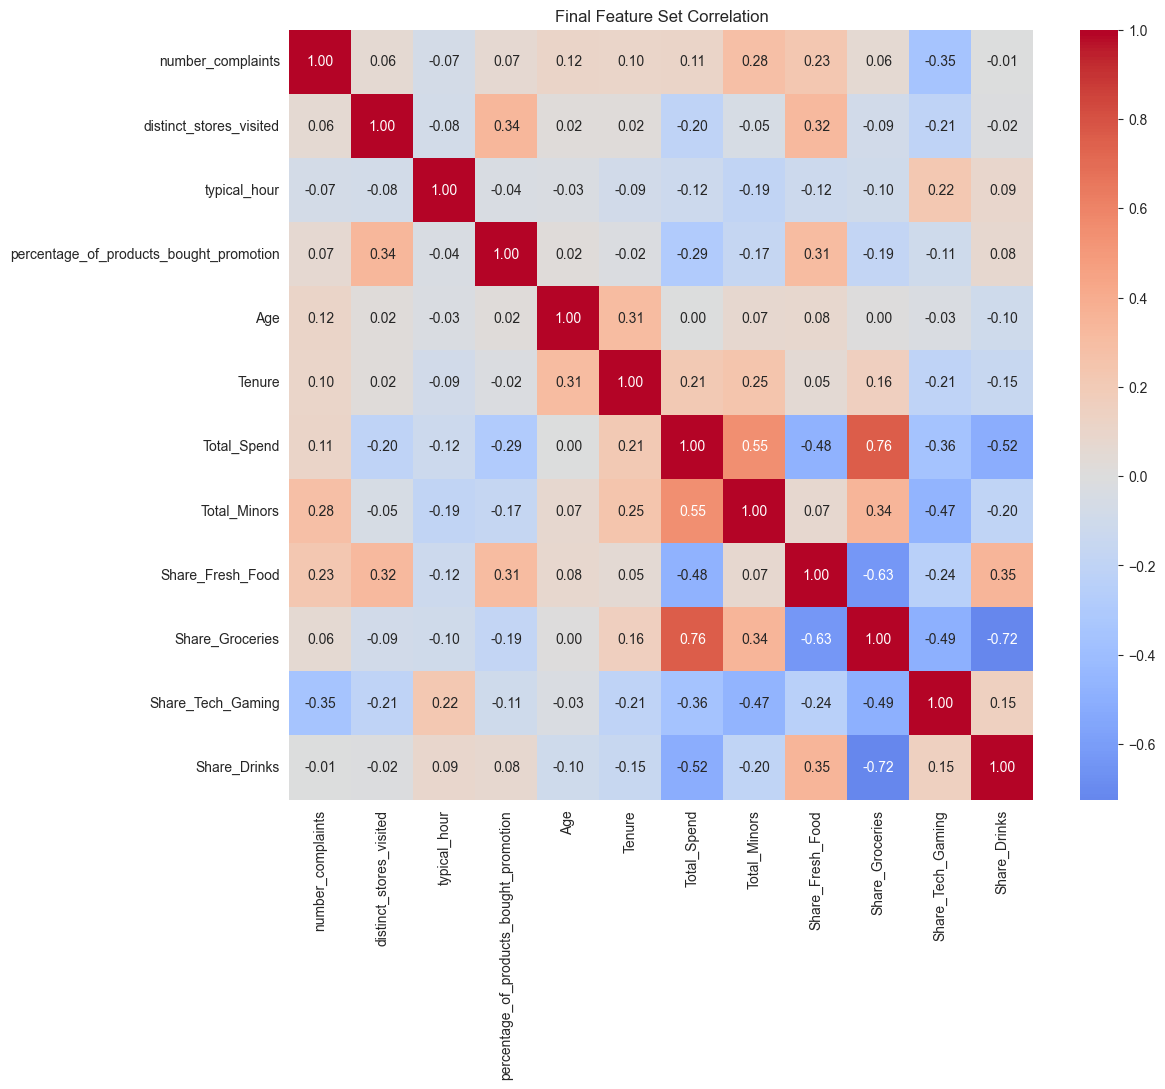

In [127]:
# ---------------------------------------------------------
# 6.3 DROP REDUNDANT FEATURES
# ---------------------------------------------------------
# We work with 'data_mode_final' since you selected Approach A
data_clustering = data_mode_final.copy()

# 1. Drop Raw Spending (Because we have 'Total_Spend' + 'Shares')
# The 0.98 correlation confirms these are 100% redundant
raw_spend_cols = [
    'lifetime_spend_groceries', 'lifetime_spend_electronics', 
    'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 
    'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 
    'lifetime_spend_fish', 'lifetime_spend_hygiene', 
    'lifetime_spend_videogames', 'lifetime_spend_petfood',
    'lifetime_total_distinct_products' # Correlated with distinct_stores
]

# Gemini expain better than me why dropping these is a good idea

# 2. Drop Components of Aggregates (Because we have 'Total_Minors')
# The 0.90 correlation confirms redundancy
family_cols = ['kids_home', 'teens_home']

# 3. Drop High Correlation duplicates
# Avg_Spend is 0.88 correlated with Total_Spend. We drop it to balance the weights.
behavior_cols = ['Avg_Spend_Per_Visit']

# Execute Drop
cols_to_drop = raw_spend_cols + family_cols + behavior_cols
# Only drop columns that actually exist in the dataframe
cols_to_drop = [c for c in cols_to_drop if c in data_clustering.columns]

data_clustering.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped {len(cols_to_drop)} redundant features.")
print(f"Final Feature Set ({data_clustering.shape[1]} columns):")
print(data_clustering.columns.tolist())

# Optional: Final Correlation Check (Should look clean/blue)
plt.figure(figsize=(12, 10))
sns.heatmap(data_clustering.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Final Feature Set Correlation")
plt.show()

Dropar aquelas colunas parece muito mas olhem lá:

The "Defense" for Your Report
If you keep both Total_Spend and Groceries (which have 0.98 correlation), you are effectively cheating the algorithm.

The Double-Counting Problem:
- Scenario: You want to group customers based on "Wealth" and "Age."
- With Raw Columns: You feed the algorithm: Groceries, Meat, Fish, Veg, Total_Spend.

The Result: 
- The algorithm sees "Money" 5 times and "Age" 1 time. It decides that Money is 5x more important than Age. Your clusters will just be "Rich People" vs. "Poor People," and you will miss the "Young Rich" vs. "Old Rich" distinction.
- Your Solution: By keeping only Total_Spend (Money) and Share_Groceries (Lifestyle), you force the algorithm to treat Wealth and Behavior equally.

The Curse of Dimensionality:
- Clustering relies on calculating "Distance" between points.
- Every column you add is a new spatial dimension. If you have 30 columns, the "distance" between customers becomes mathematically meaningless (everyone looks equally far apart). Dropping columns actually makes your clusters sharper.

Isto são tudo coisas que o professor falou nas aulas.

### 7. Scaling

Scale features so variables with large numeric ranges don’t dominate distance-based clustering.
Robust scaling is used to reduce sensitivity to remaining outliers.

In [128]:
# ---------------------------------------------------------
# 7. SCALING (RobustScaler)
# ---------------------------------------------------------
# Initialize
scaler = RobustScaler()

# Fit and Transform
# Note: It's often better to scale ONLY the numeric continuous columns.
# However, Group 13 scaled everything (including binary 0/1), so we follow that pattern.
data_scaled_array = scaler.fit_transform(data_clustering)

# Convert back to DataFrame (Scaler returns a numpy array)
data_scaled = pd.DataFrame(
    data_scaled_array, 
    columns=data_clustering.columns, 
    index=data_clustering.index
)

print("Scaling Complete.")
display(data_scaled.head())

Scaling Complete.


,number_complaints,distinct_stores_visited,typical_hour,percentage_of_products_bought_promotion,Age,Tenure,Total_Spend,Total_Minors,Share_Fresh_Food,Share_Groceries,Share_Tech_Gaming,Share_Drinks
customer_id,,,,,,,,,,,,
11259,0.5,1.0,0.375,0.690053,0.741935,1.875,-0.498170,0.000000,0.845520,-1.019213,0.057832,1.612435
6538,1.0,1.0,-0.125,0.473018,0.129032,-0.250,-0.455225,0.333333,2.019347,-1.686925,-0.172669,2.603958
14274,0.0,-1.0,-0.375,-0.476079,-0.483871,0.125,0.120027,-0.666667,-0.278299,0.209381,0.616378,-0.439814
7796,0.0,1.0,0.000,0.037816,-0.903226,-1.125,-0.384615,-0.333333,1.426236,-0.911210,0.744829,-0.271715
4521,0.5,1.0,-0.625,0.066928,0.451613,1.375,0.953634,0.666667,0.452134,0.127062,-0.108701,-0.516428


### 8. Save Output

Export the final processed dataset.
This file is used as input for the clustering step in the next notebook.

In [129]:
# ---------------------------------------------------------
# 8. SAVE TO CSV
# ---------------------------------------------------------
# This is the file you will load into the "Group 5 (Clustering)" notebook
data_scaled.to_csv('processed_customer_data.csv')
print("File 'processed_customer_data.csv' saved successfully.")

File 'processed_customer_data.csv' saved successfully.
